# VSL 30 từ — V3.1 FINAL SAFE

Đây là vòng tinh chỉnh cuối cùng dựa trên V3.

Mục tiêu:
- giữ nguyên kiến trúc keypoint-only;
- không RGB;
- không pair-head;
- không oversample hard pair;
- chỉ thêm hard-pair loss rất nhẹ;
- ưu tiên không làm giảm Accuracy/Macro-F1 tổng.

Các cặp cần chú ý:
- Thích ↔ Muốn
- Bố ↔ Anh
- Ăn ↔ Bố
- Trường học ↔ Nhà

Hai cặp `Nghe ↔ Chị` và `Thức dậy ↔ Ngày` vẫn được giữ trong danh sách hard-pair,
nhưng mức tác động rất nhẹ.

## Cấu hình an toàn
- HARD_PAIR_WEIGHT = 0.02
- HARD_PAIR_MARGIN = 0.08
- HARD_PAIR_BATCH_PROB = 0.0

Tức là sampler quay về gần như V1/V3 bình thường; hard-pair chỉ là loss phụ nhỏ.


In [1]:
# ============================================================
# 0. CONFIG
# ============================================================
from pathlib import Path

SEED = 42

TARGET_GLOSSES = [
    "Em", "Anh", "Chị", "Bố", "Nghe", "Nói", "Đi", "Ăn", "Thích", "Muốn",
    "Cần", "Cho", "Giúp đỡ", "Làm việc", "Nghỉ ngơi", "Thức dậy", "Tiếp tục",
    "Đồng ý", "Từ chối", "Cảm ơn", "Xin lỗi", "Nhà", "Trường học", "Bệnh viện",
    "Thành phố", "Siêu thị", "Bây giờ", "Ngày", "Sớm", "Nên",
]

# 87 entries user supplied, 86 unique IDs because 535810 appeared twice.
BAD_VIDEO_IDS = {
    "Xin lỗi": {485896, 455505},
    "Nghỉ ngơi": {343467, 265649, 348728, 702733, 810526, 994787},
    "Thức dậy": {139581, 244247, 324597, 410160, 774751, 794083, 836971, 903373, 903531, 985447},
    "Cảm ơn": {266931, 526117, 687080, 835343, 975136, 255287},
    "Nghe": {158845, 203225, 252640, 278240},
    "Nói": {204180},
    "Đi": {276827, 644103, 772612, 843778, 855638, 983456},
    "Nhà": {940886, 665610, 736553, 310548, 243423},
    "Trường học": {745239, 738457, 624108, 415779, 451577, 350021, 245534, 140163},
    "Ăn": {183667, 271339, 319684, 330283, 379946, 660086, 738720, 765822},
    "Bệnh viện": {156802, 446479, 544154, 858490},
    "Đồng ý": {
        162823, 176517, 250647, 265759, 313933, 321048, 356773, 403742,
        416768, 427766, 525818, 535810, 536822, 560959, 587002, 606404,
        622230, 672079, 748133, 770030, 773088, 818264, 822063, 853258,
        904214, 946567,
    },
}

# Dataset / checkpoint discovery
DATASET_HINT = "vsl-vietnamese-sign-language-v2"
PRETRAIN_NAME = "best_vsl_metric_encoder.pt"
REQUIRE_PRETRAIN = True

# Input sequence
SEQ_LEN = 48
KP_USED_POINTS = 75       # 33 pose + 21 left hand + 21 right hand; point #76 is ignored
N_POSE = 33
N_HAND = 21
COORD_CLIP = 8.0
MIN_SHOULDER_SCALE = 0.08
MIN_HAND_SCALE = 0.04
LOCAL_HAND_CLIP = 6.0

# Split
VAL_FRACTION = 0.15
MIN_AFTER_FILTER_WARNING = 60

# Extra train data already provided by dataset
USE_AUGMENTED_KEYPOINTS = True
MAX_AUG_PER_ORIGINAL = 2  # cap to avoid train being dominated by generated samples

# RGB hand branch
USE_RGB_HAND_BRANCH = False

# Keypoint augmentation
TEMP_SPEED_MIN = 0.78
TEMP_SPEED_MAX = 1.22
TEMP_CROP_MIN_KEEP = 0.86
ROT_DEG = 7.0
SCALE_MIN = 0.93
SCALE_MAX = 1.07
TRANS_STD = 0.015
KP_NOISE_STD = 0.004
POINT_DROP = 0.003
FRAME_DROP = 0.04

# Model: mostly compatible with old 3000+ word encoder
REGION_DIM = 96
D_MODEL = 256
NHEAD = 8
NUM_TRANSFORMER_LAYERS = 3
FF_DIM = 512
DROPOUT = 0.12
EMBED_DIM = 256
USE_HAND_ANGLE_FEATURES = True

# Balanced P x K batches
PK_P = 10
PK_K = 4
BATCHES_PER_EPOCH = 120

# Training stages
STAGE1_EPOCHS = 3
STAGE2_EPOCHS = 8
STAGE3_EPOCHS = 18
EARLY_STOP_PATIENCE = 6

LR_NEW_STAGE1 = 3e-4
LR_OLD_STAGE2 = 3e-5
LR_NEW_STAGE2 = 1.5e-4
LR_OLD_STAGE3 = 1e-5
LR_NEW_STAGE3 = 5e-5
WEIGHT_DECAY = 1e-4

# Loss
LABEL_SMOOTHING = 0.05
SUPCON_WEIGHT = 0.20
KEYPOINT_AUX_WEIGHT = 0.10
RGB_AUX_WEIGHT = 0.05
CROSS_MODAL_WEIGHT = 0.03
SUPCON_TEMP = 0.08

# V3: hard-pair chỉ hỗ trợ nhẹ
HARD_PAIRS = [
    ("Thích", "Muốn"),
    ("Nghe", "Chị"),
    ("Thức dậy", "Ngày"),
    ("Bố", "Anh"),
    ("Ăn", "Bố"),
    ("Trường học", "Nhà"),
]

HARD_PAIR_WEIGHT = 0.02
HARD_PAIR_MARGIN = 0.08
HARD_PAIR_BATCH_PROB = 0.0

# Baseline V3 đã đạt được trước đó — chỉ dùng để báo cáo/so sánh cuối
BASELINE_V3_ACC = 0.8618
BASELINE_V3_MACRO_F1 = 0.8628

NUM_WORKERS = 0  # stable on Kaggle/Papermill
MAX_GRAD_NORM = 1.0

# Quick smoke-test switch.
QUICK_MODE = False
if QUICK_MODE:
    BATCHES_PER_EPOCH = 10
    STAGE1_EPOCHS = 1
    STAGE2_EPOCHS = 1
    STAGE3_EPOCHS = 1

WORK_DIR = Path("/kaggle/working/vsl30_v3_1_final_safe")
WORK_DIR.mkdir(parents=True, exist_ok=True)

print("30 glosses:", len(TARGET_GLOSSES))
print("Unique bad IDs:", sum(len(x) for x in BAD_VIDEO_IDS.values()))
print("WORK_DIR:", WORK_DIR)

30 glosses: 30
Unique bad IDs: 86
WORK_DIR: /kaggle/working/vsl30_v3_1_final_safe


In [2]:
# ============================================================
# 1. ENVIRONMENT — P100-safe, NO Pillow / NO torchvision
# ============================================================
import os, sys, subprocess
from importlib.metadata import version as pkg_version

def gpu_name_before_torch():
    try:
        return subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            text=True
        ).strip().splitlines()[0]
    except Exception:
        return ""

GPU_PRE = gpu_name_before_torch()
print("GPU before torch import:", GPU_PRE or "unknown")

if "P100" in GPU_PRE.upper():
    try:
        torch_pkg = pkg_version("torch")
    except Exception:
        torch_pkg = None

    print("Torch package before:", torch_pkg)

    if torch_pkg != "2.10.0+cu126":
        print("P100 detected -> installing torch 2.10.0 cu126 ...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q",
            "--force-reinstall",
            "torch==2.10.0",
            "--index-url", "https://download.pytorch.org/whl/cu126"
        ])

import json, math, random, re, unicodedata, warnings
from collections import defaultdict, Counter
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    confusion_matrix, classification_report, top_k_accuracy_score
)

warnings.filterwarnings("ignore")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", sys.version.split()[0])
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("DEVICE:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))
    print("Compiled archs:", torch.cuda.get_arch_list())

    cap = torch.cuda.get_device_capability(0)
    arch = f"sm_{cap[0]}{cap[1]}"
    if arch not in set(torch.cuda.get_arch_list()):
        raise RuntimeError(
            f"PyTorch build does not contain {arch}. "
            "Restart Kaggle session with Internet ON."
        )

    x = torch.tensor([1.0, 2.0], device="cuda")
    y = (x * 2 + 1).sum()
    torch.cuda.synchronize()
    print("CUDA smoke test PASS:", float(y.cpu()))

print("Environment compatibility: PASS")


GPU before torch import: Tesla T4
Python: 3.12.13
OpenCV: 4.13.0
NumPy: 2.0.2
Pandas: 2.3.3
PyTorch: 2.10.0+cu128
CUDA runtime: 12.8
DEVICE: cuda
GPU: Tesla T4
Capability: (7, 5)
Compiled archs: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
CUDA smoke test PASS: 8.0
Environment compatibility: PASS


In [3]:
# ============================================================
# 2. FIND DATASET + PRETRAIN CHECKPOINT
# ============================================================
KAGGLE_INPUT = Path("/kaggle/input")

dataset_roots = [
    p for p in KAGGLE_INPUT.rglob(DATASET_HINT)
    if p.is_dir()
]
if not dataset_roots:
    raise FileNotFoundError(
        f"Không tìm thấy dataset folder chứa '{DATASET_HINT}'. Add Input dataset trước."
    )
DATA_ROOT = sorted(dataset_roots, key=lambda p: len(p.parts))[0]

PROC_ROOT = DATA_ROOT / "processed/processed"
FRAME_ROOT = PROC_ROOT / "frame_splited"
KP_ROOT = PROC_ROOT / "keypoints_splited"

AUG_ROOT = DATA_ROOT / "processed_augmented/processed_augmented"
AUG_KP_ROOT = AUG_ROOT / "keypoints_splited"
AUG_FRAME_ROOT = AUG_ROOT / "frame_splited"

TRAIN_JSON = FRAME_ROOT / "train.json"
TEST_JSON = FRAME_ROOT / "test.json"
MANIFEST = FRAME_ROOT / "split_manifest.tsv"

required = [TRAIN_JSON, TEST_JSON, MANIFEST, KP_ROOT / "train", KP_ROOT / "test"]
for p in required:
    if not p.exists():
        raise FileNotFoundError(p)

pretrain_hits = sorted(KAGGLE_INPUT.rglob(PRETRAIN_NAME))
PRETRAIN_PATH = pretrain_hits[0] if pretrain_hits else None

print("DATA_ROOT:", DATA_ROOT)
print("KP_ROOT:", KP_ROOT)
print("FRAME_ROOT:", FRAME_ROOT)
print("AUG_KP_ROOT exists:", AUG_KP_ROOT.exists())
print("PRETRAIN:", PRETRAIN_PATH)

if REQUIRE_PRETRAIN and PRETRAIN_PATH is None:
    raise FileNotFoundError(
        f"Không tìm thấy {PRETRAIN_NAME}. "
        "Add Input output/dataset chứa model 3000+ từ cũ."
    )

DATA_ROOT: /kaggle/input/datasets/nguyenanfms/vsl-vietnamese-sign-language-v2
KP_ROOT: /kaggle/input/datasets/nguyenanfms/vsl-vietnamese-sign-language-v2/processed/processed/keypoints_splited
FRAME_ROOT: /kaggle/input/datasets/nguyenanfms/vsl-vietnamese-sign-language-v2/processed/processed/frame_splited
AUG_KP_ROOT exists: True
PRETRAIN: /kaggle/input/datasets/dsfsdfdssdfdsf/output-ca-notebook-train/vsl_train_from_keypoints/export/best_vsl_metric_encoder.pt


In [4]:
# ============================================================
# 3. BUILD EXACT 30-CLASS TABLE + BLACKLIST
# ============================================================
def norm_text(s):
    return " ".join(
        unicodedata.normalize("NFC", str(s)).strip().casefold().split()
    )

target_norm_to_name = {norm_text(x): x for x in TARGET_GLOSSES}
label_to_idx = {g:i for i,g in enumerate(TARGET_GLOSSES)}
idx_to_label = {i:g for g,i in label_to_idx.items()}

train_records = json.loads(TRAIN_JSON.read_text(encoding="utf-8"))
test_records = json.loads(TEST_JSON.read_text(encoding="utf-8"))

def canonical_rows(records, split):
    rows = []
    missing = []
    bad_removed = []

    for r in records:
        gnorm = norm_text(r["gloss"])
        if gnorm not in target_norm_to_name:
            continue

        gloss = target_norm_to_name[gnorm]
        vid = str(r["videoid"]).zfill(6)
        vid_int = int(vid)

        if vid_int in BAD_VIDEO_IDS.get(gloss, set()):
            bad_removed.append((split, gloss, vid))
            continue

        kp = KP_ROOT / split / gloss / f"{vid}.npy"
        if not kp.exists():
            # allow Unicode normalization/folder variation without global rglob
            folder = KP_ROOT / split
            matching = [
                d for d in folder.iterdir()
                if d.is_dir() and norm_text(d.name) == gnorm
            ]
            if matching:
                kp = matching[0] / f"{vid}.npy"

        if not kp.exists():
            missing.append((split, gloss, vid, str(kp)))
            continue

        rows.append({
            "videoid": vid,
            "gloss": gloss,
            "label": label_to_idx[gloss],
            "source_split": split,
            "kp_path": str(kp),
            "is_aug": False,
            "base_videoid": vid,
        })

    return pd.DataFrame(rows), bad_removed, missing

train_all_df, bad_train, missing_train = canonical_rows(train_records, "train")
test_df, bad_test, missing_test = canonical_rows(test_records, "test")

print("Canonical target train:", len(train_all_df))
print("Canonical target test :", len(test_df))
print("Blacklist removed     :", len(bad_train) + len(bad_test))
print("Missing keypoint files:", len(missing_train) + len(missing_test))

if missing_train[:5] or missing_test[:5]:
    print("Missing examples:", (missing_train + missing_test)[:5])

# Correct per-class count: records/videos, not rows of split_manifest.
count_table = (
    pd.concat([
        train_all_df.groupby("gloss").size().rename("train_after_blacklist"),
        test_df.groupby("gloss").size().rename("test_after_blacklist"),
    ], axis=1)
    .reindex(TARGET_GLOSSES)
    .fillna(0)
    .astype(int)
)
count_table["total_after_blacklist"] = (
    count_table["train_after_blacklist"] + count_table["test_after_blacklist"]
)

display(count_table)
count_table.to_csv(WORK_DIR / "counts_after_blacklist.csv", encoding="utf-8-sig")

missing_glosses = count_table[count_table["total_after_blacklist"] == 0].index.tolist()
if missing_glosses:
    raise RuntimeError(f"Không tìm thấy dữ liệu cho: {missing_glosses}")

low = count_table[count_table["total_after_blacklist"] < MIN_AFTER_FILTER_WARNING]
if len(low):
    print("WARNING — dưới", MIN_AFTER_FILTER_WARNING, "video sau blacklist:")
    display(low)

bad_df = pd.DataFrame(
    bad_train + bad_test, columns=["split","gloss","videoid"]
)
bad_df.to_csv(WORK_DIR / "removed_bad_video_ids.csv", index=False, encoding="utf-8-sig")

Canonical target train: 1875
Canonical target test : 463
Blacklist removed     : 76
Missing keypoint files: 0


,train_after_blacklist,test_after_blacklist,total_after_blacklist
gloss,,,
Em,67,17,84
Anh,67,17,84
Chị,65,16,81
Bố,58,15,73
Nghe,84,20,104
Nói,57,14,71
Đi,66,16,82
Ăn,64,16,80
Thích,65,16,81


WARNING — dưới 60 video sau blacklist:


,train_after_blacklist,test_after_blacklist,total_after_blacklist
gloss,,,
Đồng ý,47,9,56


In [5]:
# ============================================================
# 4. TRAIN / VAL / TEST SPLIT
# ============================================================
# Keep packaged test set untouched.
# Create validation only from canonical train.
rng = np.random.default_rng(SEED)

train_parts = []
val_parts = []

for gloss in TARGET_GLOSSES:
    cls = train_all_df[train_all_df.gloss == gloss].copy()
    idx = np.arange(len(cls))
    rng.shuffle(idx)

    n_val = max(3, int(round(len(cls) * VAL_FRACTION)))
    n_val = min(n_val, max(1, len(cls) - 2))

    val_idx = idx[:n_val]
    tr_idx = idx[n_val:]

    val_parts.append(cls.iloc[val_idx])
    train_parts.append(cls.iloc[tr_idx])

train_df = pd.concat(train_parts, ignore_index=True)
val_df = pd.concat(val_parts, ignore_index=True)

train_ids_by_gloss = {
    g: set(train_df.loc[train_df.gloss == g, "videoid"])
    for g in TARGET_GLOSSES
}
val_ids_by_gloss = {
    g: set(val_df.loc[val_df.gloss == g, "videoid"])
    for g in TARGET_GLOSSES
}

print("Canonical train:", len(train_df))
print("Validation     :", len(val_df))
print("Final test     :", len(test_df))

assert set(train_df.videoid) & set(val_df.videoid) == set()

Canonical train: 1590
Validation     : 285
Final test     : 463


In [6]:
# ============================================================
# 5. ADD AUGMENTED KEYPOINT TRAIN FILES SAFELY
# ============================================================
def six_digit_id(text):
    m = re.search(r"(?<!\d)(\d{6})(?!\d)", str(text))
    return m.group(1) if m else None

aug_rows = []

if USE_AUGMENTED_KEYPOINTS and AUG_KP_ROOT.exists():
    for gloss in TARGET_GLOSSES:
        split_dir = AUG_KP_ROOT / "train"
        candidates = [
            d for d in split_dir.iterdir()
            if d.is_dir() and norm_text(d.name) == norm_text(gloss)
        ] if split_dir.exists() else []

        if not candidates:
            continue

        gdir = candidates[0]
        grouped = defaultdict(list)

        # Only scan this one target-gloss folder, not the full 82 GB dataset.
        for p in gdir.glob("*.npy"):
            base = six_digit_id(p.stem)
            if base is None:
                continue

            # Never include augmented derivatives of validation samples.
            if base in val_ids_by_gloss[gloss]:
                continue

            # Only allow augmentations whose base clip belongs to train.
            if base not in train_ids_by_gloss[gloss]:
                continue

            if int(base) in BAD_VIDEO_IDS.get(gloss, set()):
                continue

            grouped[base].append(p)

        for base, paths in grouped.items():
            paths = sorted(paths)[:MAX_AUG_PER_ORIGINAL]
            for p in paths:
                aug_rows.append({
                    "videoid": p.stem,
                    "gloss": gloss,
                    "label": label_to_idx[gloss],
                    "source_split": "train_aug",
                    "kp_path": str(p),
                    "is_aug": True,
                    "base_videoid": base,
                })

aug_df = pd.DataFrame(aug_rows)

if len(aug_df):
    train_full_df = pd.concat([train_df, aug_df], ignore_index=True)
else:
    train_full_df = train_df.copy()

print("Augmented train samples accepted:", len(aug_df))
print("Total train samples:", len(train_full_df))

split_counts = pd.DataFrame({
    "train": train_full_df.groupby("gloss").size(),
    "val": val_df.groupby("gloss").size(),
    "test": test_df.groupby("gloss").size(),
}).reindex(TARGET_GLOSSES).fillna(0).astype(int)

display(split_counts)
split_counts.to_csv(WORK_DIR / "split_counts.csv", encoding="utf-8-sig")

Augmented train samples accepted: 1550
Total train samples: 3140


,train,val,test
gloss,,,
Em,114,10,17
Anh,114,10,17
Chị,110,10,16
Bố,98,9,15
Nghe,138,13,20
Nói,93,9,14
Đi,106,10,16
Ăn,105,10,16
Thích,109,10,16


In [7]:
# ============================================================
# 6. KEYPOINT HEALTH CHECK — target files only
# ============================================================
def basic_kp_health(path):
    try:
        x = np.load(path, allow_pickle=False)
        if x.ndim != 3 or x.shape[-1] < 3 or x.shape[1] < KP_USED_POINTS:
            return False, f"shape={getattr(x,'shape',None)}"
        if x.shape[0] < 4:
            return False, f"too_short={x.shape[0]}"
        finite_ratio = np.isfinite(x[..., :3]).mean()
        if finite_ratio < 0.95:
            return False, f"finite={finite_ratio:.3f}"
        return True, "ok"
    except Exception as e:
        return False, repr(e)

health_bad = []

# Check every canonical target file + accepted aug; only a few thousand small npy files.
for row in tqdm(
    pd.concat([train_full_df, val_df, test_df], ignore_index=True).itertuples(index=False),
    total=len(train_full_df)+len(val_df)+len(test_df),
    desc="Keypoint health"
):
    ok, reason = basic_kp_health(row.kp_path)
    if not ok:
        health_bad.append({
            "videoid": row.videoid,
            "gloss": row.gloss,
            "source_split": row.source_split,
            "kp_path": row.kp_path,
            "reason": reason,
        })

health_bad_df = pd.DataFrame(health_bad)
print("Health-check failed:", len(health_bad_df))
if len(health_bad_df):
    display(health_bad_df.head(30))
    bad_paths = set(health_bad_df.kp_path)
    train_full_df = train_full_df[~train_full_df.kp_path.isin(bad_paths)].reset_index(drop=True)
    val_df = val_df[~val_df.kp_path.isin(bad_paths)].reset_index(drop=True)
    test_df = test_df[~test_df.kp_path.isin(bad_paths)].reset_index(drop=True)
    health_bad_df.to_csv(WORK_DIR / "removed_health_check.csv", index=False, encoding="utf-8-sig")

print("After health check:", len(train_full_df), len(val_df), len(test_df))

Keypoint health:   0%|          | 0/3888 [00:00<?, ?it/s]

Health-check failed: 0
After health check: 3140 285 463


In [8]:
# ============================================================
# 7. DATASET FORMAT DIAGNOSTIC
# ============================================================
sample_path = Path(train_df.iloc[0].kp_path)
sample = np.load(sample_path, allow_pickle=False)

print("Sample:", sample_path)
print("Shape:", sample.shape, "dtype:", sample.dtype)
print("Finite:", np.isfinite(sample).all())
print("Global min/max:", float(np.nanmin(sample)), float(np.nanmax(sample)))

if sample.shape[1] == 76:
    print(
        "Using points [0:75] as 33 pose + 21 left hand + 21 right hand. "
        "Dataset-specific point #76 is ignored for compatibility."
    )

# Estimate whether zero triples represent missing joints.
first75 = sample[:, :75, :3]
zero_ratio = float((np.linalg.norm(np.nan_to_num(first75), axis=-1) < 1e-8).mean())
print("Zero-joint ratio in sample:", zero_ratio)

Sample: /kaggle/input/datasets/nguyenanfms/vsl-vietnamese-sign-language-v2/processed/processed/keypoints_splited/train/Em/015018.npy
Shape: (69, 76, 3) dtype: float32
Finite: True
Global min/max: -1.6733192205429077 1.046417474746704
Using points [0:75] as 33 pose + 21 left hand + 21 right hand. Dataset-specific point #76 is ignored for compatibility.
Zero-joint ratio in sample: 0.01932367149758454


In [9]:
# ============================================================
# 8. PREPROCESSING + AUGMENTATION
# ============================================================
POSE_SLICE = slice(0, N_POSE)
LH_SLICE = slice(N_POSE, N_POSE + N_HAND)
RH_SLICE = slice(N_POSE + N_HAND, N_POSE + 2*N_HAND)
BODY_IDS_NP = np.array([0,11,12,13,14,15,16,23,24], dtype=np.int64)
BODY_IDS = torch.tensor(BODY_IDS_NP, dtype=torch.long)

def sanitize_raw76(arr):
    x = np.asarray(arr, dtype=np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = x[:, :KP_USED_POINTS, :3]
    return x

def infer_mask(xyz):
    finite = np.isfinite(xyz).all(axis=-1)
    nonzero = np.linalg.norm(np.nan_to_num(xyz), axis=-1) > 1e-8
    return (finite & nonzero).astype(np.float32)[..., None]

def normalize_body(raw_xyz):
    xyz = sanitize_raw76(raw_xyz)
    mask = infer_mask(xyz)

    shoulder_ok = (mask[:,11,0] > 0.5) & (mask[:,12,0] > 0.5)

    if shoulder_ok.any():
        centers = (xyz[shoulder_ok,11] + xyz[shoulder_ok,12]) / 2.0
        d = np.linalg.norm(
            xyz[shoulder_ok,11,:2] - xyz[shoulder_ok,12,:2],
            axis=1
        )
        good = np.isfinite(d) & (d >= MIN_SHOULDER_SCALE)
    else:
        good = np.zeros(0, dtype=bool)

    if shoulder_ok.any() and good.any():
        center = np.median(centers[good], axis=0)
        scale = float(np.median(d[good]))

        vec = (
            xyz[shoulder_ok,12,:2] - xyz[shoulder_ok,11,:2]
        )[good]
        theta = -float(np.median(np.arctan2(vec[:,1], vec[:,0])))
    else:
        vis = mask[...,0] > 0.5
        pts = xyz[vis]
        if len(pts):
            center = np.median(pts, axis=0)
            radial = np.linalg.norm(pts[:,:2] - center[:2], axis=1)
            radial = radial[radial > 1e-4]
            scale = float(np.median(radial)) if len(radial) else 0.25
        else:
            center = np.zeros(3, np.float32)
            scale = 0.25
        theta = 0.0

    scale = max(scale, MIN_SHOULDER_SCALE)

    centers_t = np.repeat(center[None], len(xyz), axis=0)
    if shoulder_ok.any():
        centers_t[shoulder_ok] = (
            xyz[shoulder_ok,11] + xyz[shoulder_ok,12]
        ) / 2.0

    out = (xyz - centers_t[:,None,:]) / scale

    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c,-s],[s,c]], dtype=np.float32)
    out[...,:2] = out[...,:2] @ R.T

    out = np.clip(out, -COORD_CLIP, COORD_CLIP)
    out *= mask

    return np.concatenate([out, mask], axis=-1).astype(np.float32)

def linear_resample(x, target_len):
    if len(x) == target_len:
        return x.astype(np.float32)
    if len(x) <= 1:
        return np.repeat(x[:1], target_len, axis=0).astype(np.float32)

    old_t = np.linspace(0, 1, len(x), dtype=np.float32)
    new_t = np.linspace(0, 1, target_len, dtype=np.float32)
    flat = x.reshape(len(x), -1)
    out = np.empty((target_len, flat.shape[1]), np.float32)

    for j in range(flat.shape[1]):
        out[:,j] = np.interp(new_t, old_t, flat[:,j])

    out = out.reshape(target_len, *x.shape[1:])
    out[...,3] = np.clip(out[...,3], 0, 1)
    out[...,:3] *= (out[...,3:4] > 0.2)
    return out.astype(np.float32)

def temporal_augment(x):
    # x = normalized variable-length sequence
    T = len(x)

    # Random crop: makes model less sensitive to small start/end shifts.
    if T >= 8 and random.random() < 0.70:
        keep = random.uniform(TEMP_CROP_MIN_KEEP, 1.0)
        n = max(6, int(round(T * keep)))
        start = random.randint(0, max(0, T-n))
        x = x[start:start+n]

    # Speed via intermediate target length before final 48-frame resample.
    speed = random.uniform(TEMP_SPEED_MIN, TEMP_SPEED_MAX)
    speed_len = max(8, int(round(len(x) / speed)))
    x = linear_resample(x, speed_len)
    return x

def spatial_augment(x):
    y = x.copy()
    xyz = y[...,:3]
    mask = y[...,3:4]

    angle = math.radians(random.uniform(-ROT_DEG, ROT_DEG))
    c, s = math.cos(angle), math.sin(angle)
    R = np.array([[c,-s],[s,c]], np.float32)
    xyz[...,:2] = xyz[...,:2] @ R.T

    scale = random.uniform(SCALE_MIN, SCALE_MAX)
    xyz *= scale

    trans = np.random.normal(0, TRANS_STD, size=(1,1,3)).astype(np.float32)
    trans[...,2] *= 0.5
    xyz += trans

    if KP_NOISE_STD > 0:
        xyz += np.random.normal(0, KP_NOISE_STD, xyz.shape).astype(np.float32) * mask

    if POINT_DROP > 0:
        drop = (np.random.random(mask.shape[:-1]) < POINT_DROP)[...,None]
        mask = mask * (~drop)

    xyz = np.clip(xyz, -COORD_CLIP, COORD_CLIP) * mask
    y = np.concatenate([xyz, mask], axis=-1)

    if FRAME_DROP > 0 and len(y) > 4:
        dropf = np.random.random(len(y)) < FRAME_DROP
        y[dropf] = 0.0

    return y.astype(np.float32)

def prepare_keypoints(path, train=False):
    raw = np.load(path, allow_pickle=False)
    x = normalize_body(raw)

    if train:
        x = temporal_augment(x)
        x = linear_resample(x, SEQ_LEN)
        x = spatial_augment(x)
    else:
        x = linear_resample(x, SEQ_LEN)

    return np.nan_to_num(
        x, nan=0.0, posinf=0.0, neginf=0.0
    ).astype(np.float32)

In [10]:
# ============================================================
# 9. RGB disabled in V3
# ============================================================
RGB_AVAILABLE = False
print("V3 mode: KEYPOINT-ONLY")
print("RGB_AVAILABLE:", RGB_AVAILABLE)


V3 mode: KEYPOINT-ONLY
RGB_AVAILABLE: False


In [11]:
# ============================================================
# 10. RGB disabled in V3
# ============================================================
def load_hand_rgb(*args, **kwargs):
    return None, None


In [12]:
# ============================================================
# 11. KEYPOINT DATASET + V3 BALANCED SAMPLER
# ============================================================
class VSL30Dataset(Dataset):
    def __init__(self, df, train=False):
        self.df = df.reset_index(drop=True)
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]

        kp = prepare_keypoints(
            r.kp_path,
            train=self.train
        )

        return {
            "kp": torch.from_numpy(kp),
            "label": torch.tensor(
                int(r.label),
                dtype=torch.long
            ),
            "videoid": str(r.videoid),
            "gloss": str(r.gloss),
        }

class V3PKBatchSampler(Sampler):
    """
    100% batch: normal P×K balanced sampling vì HARD_PAIR_BATCH_PROB = 0.0.

    Hard-pair chỉ tác động qua loss phụ rất nhẹ; không ép xuất hiện trong batch.
    """
    def __init__(
        self,
        labels,
        p=10,
        k=4,
        batches=120,
        hard_pairs=None,
        hard_prob=0.20,
    ):
        self.labels = np.asarray(labels)
        self.p = int(p)
        self.k = int(k)
        self.batches = int(batches)
        self.hard_prob = float(hard_prob)

        self.by_class = {
            int(c): np.where(self.labels == c)[0]
            for c in np.unique(self.labels)
        }
        self.classes = sorted(self.by_class)

        self.hard_pairs = []
        for a, b in (hard_pairs or []):
            ia = label_to_idx[a]
            ib = label_to_idx[b]
            if ia in self.by_class and ib in self.by_class:
                self.hard_pairs.append((ia, ib))

    def __len__(self):
        return self.batches

    def __iter__(self):
        rng = np.random.default_rng(
            SEED + random.randint(0, 10_000_000)
        )

        for _ in range(self.batches):
            selected = []

            # Only ~20% of batches explicitly force one hard pair.
            if (
                self.hard_pairs
                and rng.random() < self.hard_prob
            ):
                ia, ib = self.hard_pairs[
                    int(rng.integers(0, len(self.hard_pairs)))
                ]
                selected.extend([ia, ib])

            remaining = [
                c for c in self.classes
                if c not in selected
            ]

            need = self.p - len(selected)

            if need > 0:
                extra = rng.choice(
                    remaining,
                    size=min(need, len(remaining)),
                    replace=False,
                ).tolist()
                selected.extend(extra)

            selected = selected[:self.p]

            batch = []

            for c in selected:
                inds = self.by_class[int(c)]

                chosen = rng.choice(
                    inds,
                    size=self.k,
                    replace=len(inds) < self.k,
                )

                batch.extend(chosen.tolist())

            rng.shuffle(batch)
            yield batch

train_ds = VSL30Dataset(
    train_full_df,
    train=True
)
val_ds = VSL30Dataset(
    val_df,
    train=False
)
test_ds = VSL30Dataset(
    test_df,
    train=False
)

train_sampler = V3PKBatchSampler(
    train_full_df.label.values,
    p=PK_P,
    k=PK_K,
    batches=BATCHES_PER_EPOCH,
    hard_pairs=HARD_PAIRS,
    hard_prob=HARD_PAIR_BATCH_PROB,
)

train_loader = DataLoader(
    train_ds,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

b = next(iter(train_loader))

print("kp:", b["kp"].shape)
print(
    "labels:",
    b["label"].shape,
    "unique:",
    b["label"].unique().numel()
)


kp: torch.Size([40, 48, 75, 4])
labels: torch.Size([40]) unique: 10


In [13]:
# ============================================================
# 12. KEYPOINT ENCODER — PRETRAIN-COMPATIBLE, NO FACE
# ============================================================
def first_order_motion(coords, mask):
    d = torch.zeros_like(coords)
    valid_pair = mask[:,1:] * mask[:,:-1]
    d[:,1:] = (coords[:,1:] - coords[:,:-1]) * valid_pair
    return d

def hand_local_features(hand):
    xyz = torch.nan_to_num(hand[..., :3], nan=0.0, posinf=0.0, neginf=0.0)
    mask = hand[..., 3:4].clamp(0.0,1.0)
    wrist = xyz[...,0:1,:]
    wrist_ok = mask[...,0:1,:] > 0.5
    mcp_ok = mask[...,9:10,:] > 0.5
    anchor_ok = wrist_ok & mcp_ok

    raw_scale = torch.linalg.norm(
        xyz[...,9:10,:] - wrist, dim=-1, keepdim=True
    )
    scale = torch.where(
        anchor_ok,
        raw_scale.clamp_min(MIN_HAND_SCALE),
        torch.ones_like(raw_scale)
    )
    local = (xyz - wrist) / scale
    local = local * mask * wrist_ok.to(local.dtype)
    return torch.nan_to_num(local).clamp(-LOCAL_HAND_CLIP, LOCAL_HAND_CLIP)

def safe_angle(a,b,eps=1e-6):
    an = torch.linalg.norm(a,dim=-1).clamp_min(eps)
    bn = torch.linalg.norm(b,dim=-1).clamp_min(eps)
    cos = (a*b).sum(-1)/(an*bn)
    return torch.acos(torch.nan_to_num(cos).clamp(-0.9999,0.9999))

def hand_angle_descriptor(hand):
    xyz = torch.nan_to_num(hand[...,:3])
    mask = hand[...,3] > 0.5
    fingers = [
        [0,1,2,3,4], [0,5,6,7,8], [0,9,10,11,12],
        [0,13,14,15,16], [0,17,18,19,20]
    ]
    feats = []
    for f in fingers:
        for j in range(1,4):
            a0,a1,a2 = f[j-1],f[j],f[j+1]
            ang = safe_angle(
                xyz[...,a0,:]-xyz[...,a1,:],
                xyz[...,a2,:]-xyz[...,a1,:]
            )
            valid = mask[...,a0] & mask[...,a1] & mask[...,a2]
            feats.append(torch.where(valid,ang,torch.zeros_like(ang)))

    mcps = [1,5,9,13,17]
    rays = [xyz[...,i,:]-xyz[...,0,:] for i in mcps]
    for i in range(4):
        ang = safe_angle(rays[i],rays[i+1])
        valid = mask[...,0] & mask[...,mcps[i]] & mask[...,mcps[i+1]]
        feats.append(torch.where(valid,ang,torch.zeros_like(ang)))

    ang = safe_angle(rays[1],rays[4])
    valid = mask[...,0] & mask[...,mcps[1]] & mask[...,mcps[4]]
    feats.append(torch.where(valid,ang,torch.zeros_like(ang)))
    return torch.stack(feats,dim=-1)

def flatten_region_basic(region):
    xyz = region[...,:3]
    mask = region[...,3:4]
    motion = first_order_motion(xyz,mask)
    return torch.cat([
        (xyz*mask).flatten(-2),
        mask.flatten(-2),
        motion.flatten(-2)
    ],dim=-1)

class RegionMLP(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim,out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(out_dim,out_dim),
            nn.LayerNorm(out_dim),
        )
    def forward(self,x):
        return self.net(x)

class AttentionPool(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.score = nn.Linear(dim,1)
        # Zero init => uniform attention initially, matching old mean-pooling behavior.
        nn.init.zeros_(self.score.weight)
        nn.init.zeros_(self.score.bias)

    def forward(self,x,mask=None):
        s = self.score(x).squeeze(-1)
        if mask is not None:
            s = s.masked_fill(~mask, -1e4)
        w = torch.softmax(s,dim=1)
        return (x*w.unsqueeze(-1)).sum(1), w

class KeypointEncoder30(nn.Module):
    def __init__(self):
        super().__init__()
        body_n = len(BODY_IDS_NP)
        body_in = body_n*(3+1+3)
        hand_in = N_HAND*(3+1) + N_HAND*3 + N_HAND*3
        if USE_HAND_ANGLE_FEATURES:
            hand_in += 20

        self.body_encoder = RegionMLP(body_in,REGION_DIM)
        self.hand_encoder = RegionMLP(hand_in,REGION_DIM)
        self.side_embed = nn.Parameter(torch.zeros(2,REGION_DIM))
        nn.init.normal_(self.side_embed,std=0.02)

        # NEW: only body/LH/RH, because V2 keypoints do not match old 40-face subset.
        self.gate = nn.Sequential(
            nn.Linear(3*REGION_DIM,REGION_DIM),
            nn.GELU(),
            nn.Linear(REGION_DIM,3),
        )
        self.fuse = nn.Sequential(
            nn.Linear(3*REGION_DIM,D_MODEL),
            nn.LayerNorm(D_MODEL),
            nn.GELU(),
        )

        self.local_conv = nn.Sequential(
            nn.Conv1d(D_MODEL,D_MODEL,3,padding=1,groups=D_MODEL),
            nn.GELU(),
            nn.Conv1d(D_MODEL,D_MODEL,1),
            nn.Dropout(DROPOUT),
        )

        self.pos = nn.Parameter(torch.zeros(1,SEQ_LEN,D_MODEL))
        nn.init.trunc_normal_(self.pos,std=0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL,nhead=NHEAD,dim_feedforward=FF_DIM,
            dropout=DROPOUT,activation="gelu",
            batch_first=True,norm_first=True
        )
        self.temporal = nn.TransformerEncoder(
            layer,num_layers=NUM_TRANSFORMER_LAYERS
        )

        self.attn_pool = AttentionPool(D_MODEL)

        self.head = nn.Sequential(
            nn.LayerNorm(D_MODEL),
            nn.Linear(D_MODEL,D_MODEL),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL,EMBED_DIM),
        )

    def encode_hand(self,hand,side):
        xyz = hand[...,:3]
        mask = hand[...,3:4]
        local = hand_local_features(hand)
        motion = first_order_motion(xyz,mask)
        parts = [
            (xyz*mask).flatten(-2),
            mask.flatten(-2),
            local.flatten(-2),
            motion.flatten(-2),
        ]
        if USE_HAND_ANGLE_FEATURES:
            parts.append(hand_angle_descriptor(hand))
        h = self.hand_encoder(torch.cat(parts,dim=-1))
        return h + self.side_embed[side][None,None,:]

    def forward(self,x,return_attention=False):
        x = torch.nan_to_num(x.float())
        xyz = x[...,:3].clamp(-COORD_CLIP,COORD_CLIP)
        mask = x[...,3:4].clamp(0,1)
        x = torch.cat([xyz,mask],dim=-1)

        body = x.index_select(2,BODY_IDS.to(x.device))
        lh = x[:,:,LH_SLICE,:]
        rh = x[:,:,RH_SLICE,:]

        rb = self.body_encoder(flatten_region_basic(body))
        rl = self.encode_hand(lh,0)
        rr = self.encode_hand(rh,1)

        regions = [rb,rl,rr]
        cat = torch.cat(regions,dim=-1)
        gates = torch.softmax(self.gate(cat),dim=-1)
        weighted = [r*gates[...,i:i+1] for i,r in enumerate(regions)]

        h = self.fuse(torch.cat(weighted,dim=-1))
        h = h + self.local_conv(h.transpose(1,2)).transpose(1,2)
        h = h + self.pos[:,:h.size(1)]
        h = self.temporal(h)

        frame_valid = (mask.sum(dim=(2,3)) > 0)
        pooled, attn = self.attn_pool(h,frame_valid)

        z_raw = self.head(pooled)
        z = F.normalize(torch.nan_to_num(z_raw).float(),dim=-1,eps=1e-6)

        if return_attention:
            return z,attn,gates
        return z

In [14]:
# ============================================================
# 13. LOAD COMPATIBLE WEIGHTS FROM 3000+ WORD MODEL
# ============================================================
kp_encoder = KeypointEncoder30()

loaded_report = []
skipped_report = []

if PRETRAIN_PATH is not None:
    old = torch.load(PRETRAIN_PATH, map_location="cpu", weights_only=False)
    old_sd = old.get("model_state", old)
    new_sd = kp_encoder.state_dict()

    transfer_prefixes = (
        "body_encoder.",
        "hand_encoder.",
        "side_embed",
        "local_conv.",
        "pos",
        "temporal.",
        "head.",
    )

    for k,v in old_sd.items():
        if not k.startswith(transfer_prefixes):
            continue
        if k in new_sd and tuple(new_sd[k].shape) == tuple(v.shape):
            new_sd[k] = v
            loaded_report.append(k)
        else:
            skipped_report.append(k)

    kp_encoder.load_state_dict(new_sd)

print("Transferred tensors:", len(loaded_report))
print("Skipped incompatible tensors:", len(skipped_report))
print("Examples loaded:", loaded_report[:12])
print("Examples skipped:", skipped_report[:12])

if REQUIRE_PRETRAIN and len(loaded_report) < 20:
    raise RuntimeError(
        "Checkpoint được tìm thấy nhưng quá ít tensor tương thích. "
        "Hãy chắc chắn đây là best_vsl_metric_encoder.pt từ notebook trước."
    )

kp_encoder = kp_encoder.to(DEVICE)

with torch.no_grad():
    smoke = b["kp"][:2].to(DEVICE)
    z,attn,gates = kp_encoder(smoke,return_attention=True)
print("Keypoint embedding:",z.shape)
print("Attention:",attn.shape)
print("Region gates:",gates.shape)
print("Finite:",bool(torch.isfinite(z).all()))

Transferred tensors: 64
Skipped incompatible tensors: 0
Examples loaded: ['side_embed', 'pos', 'body_encoder.net.0.weight', 'body_encoder.net.0.bias', 'body_encoder.net.1.weight', 'body_encoder.net.1.bias', 'body_encoder.net.4.weight', 'body_encoder.net.4.bias', 'body_encoder.net.5.weight', 'body_encoder.net.5.bias', 'hand_encoder.net.0.weight', 'hand_encoder.net.0.bias']
Examples skipped: []
Keypoint embedding: torch.Size([2, 256])
Attention: torch.Size([2, 48])
Region gates: torch.Size([2, 48, 3])
Finite: True


In [15]:
# ============================================================
# 14. RGB removed in V3
# ============================================================
print("No RGB encoder in V3.")


No RGB encoder in V3.


In [16]:
# ============================================================
# 15. V3 KEYPOINT-ONLY CLASSIFIER
# ============================================================
class VSL30Model(nn.Module):
    def __init__(self, kp_encoder):
        super().__init__()

        self.kp_encoder = kp_encoder

        self.classifier = nn.Sequential(
            nn.LayerNorm(EMBED_DIM),
            nn.Dropout(0.10),
            nn.Linear(
                EMBED_DIM,
                len(TARGET_GLOSSES)
            ),
        )

        self.kp_classifier = nn.Linear(
            EMBED_DIM,
            len(TARGET_GLOSSES)
        )

    def forward(self, kp):
        z = self.kp_encoder(kp)

        return {
            "logits": self.classifier(z),
            "kp_logits": self.kp_classifier(z),
            "embedding": z,
        }

model = VSL30Model(
    kp_encoder
).to(DEVICE)

params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Total params: {params/1e6:.2f}M"
)

with torch.no_grad():
    out_smoke = model(
        b["kp"][:2].to(DEVICE)
    )

print(
    "Logits:",
    out_smoke["logits"].shape
)

print(
    "Embedding finite:",
    bool(
        torch.isfinite(
            out_smoke["embedding"]
        ).all()
    )
)


Total params: 1.96M
Logits: torch.Size([2, 30])
Embedding finite: True


In [17]:
# ============================================================
# 16. V3 LOSSES — standard training + LIGHT hard-pair margin
# ============================================================
def supervised_contrastive_loss(
    z,
    labels,
    temp=0.08
):
    z = F.normalize(
        z.float(),
        dim=-1
    )

    labels = labels.view(-1,1)

    sim = (
        z @ z.T
    ) / temp

    eye = torch.eye(
        len(z),
        device=z.device,
        dtype=torch.bool
    )

    sim = (
        sim
        - sim.max(
            dim=1,
            keepdim=True
        ).values.detach()
    )

    exp_sim = (
        torch.exp(sim)
        * (~eye)
    )

    pos = (
        (labels == labels.T)
        & (~eye)
    )

    denom = exp_sim.sum(
        dim=1
    ).clamp_min(1e-12)

    numer = (
        exp_sim * pos
    ).sum(dim=1)

    valid = (
        pos.sum(dim=1) > 0
    )

    if not valid.any():
        return z.sum() * 0.0

    return (
        -torch.log(
            (
                numer[valid]
                / denom[valid]
            ).clamp_min(1e-12)
        )
    ).mean()

def hard_pair_margin_loss(
    logits,
    labels
):
    """
    Nhẹ hơn V2 rất nhiều:
    chỉ yêu cầu logit đúng cao hơn counterpart một margin nhỏ.
    """
    terms = []

    logits = logits.float()

    for a, b in HARD_PAIRS:
        ia = label_to_idx[a]
        ib = label_to_idx[b]

        mask = (
            (labels == ia)
            | (labels == ib)
        )

        if not mask.any():
            continue

        rows = logits[mask]
        y = labels[mask]

        true_score = rows.gather(
            1,
            y[:,None]
        ).squeeze(1)

        counterpart = torch.where(
            y == ia,
            torch.full_like(y, ib),
            torch.full_like(y, ia),
        )

        counterpart_score = rows.gather(
            1,
            counterpart[:,None]
        ).squeeze(1)

        terms.append(
            F.relu(
                HARD_PAIR_MARGIN
                - (
                    true_score
                    - counterpart_score
                )
            ).mean()
        )

    if not terms:
        return logits.sum() * 0.0

    return torch.stack(
        terms
    ).mean()

def compute_loss(
    outputs,
    labels
):
    main_ce = F.cross_entropy(
        outputs["logits"].float(),
        labels,
        label_smoothing=LABEL_SMOOTHING
    )

    kp_ce = F.cross_entropy(
        outputs["kp_logits"].float(),
        labels
    )

    sup = supervised_contrastive_loss(
        outputs["embedding"],
        labels,
        SUPCON_TEMP
    )

    hard = hard_pair_margin_loss(
        outputs["logits"],
        labels
    )

    total = (
        main_ce
        + KEYPOINT_AUX_WEIGHT * kp_ce
        + SUPCON_WEIGHT * sup
        + HARD_PAIR_WEIGHT * hard
    )

    return total, {
        "main_ce": float(main_ce.detach()),
        "kp_ce": float(kp_ce.detach()),
        "supcon": float(sup.detach()),
        "hard_pair": float(hard.detach()),
    }


In [18]:
# ============================================================
# 17. V3 TRAINING STAGES
# ============================================================
def set_stage(stage):
    for p in model.parameters():
        p.requires_grad = False

    # Always train new 30-class heads + attention/fusion pieces added to KP encoder.
    for module in [
        model.classifier,
        model.kp_classifier,
        model.kp_encoder.gate,
        model.kp_encoder.fuse,
        model.kp_encoder.attn_pool,
    ]:
        for p in module.parameters():
            p.requires_grad = True

    if stage >= 2:
        # Adapt pretrained temporal representation.
        for module in [
            model.kp_encoder.local_conv,
            model.kp_encoder.temporal,
            model.kp_encoder.head,
        ]:
            for p in module.parameters():
                p.requires_grad = True

        model.kp_encoder.pos.requires_grad = True

    if stage >= 3:
        # Full keypoint fine-tune at very small LR.
        for module in [
            model.kp_encoder.body_encoder,
            model.kp_encoder.hand_encoder,
        ]:
            for p in module.parameters():
                p.requires_grad = True

        model.kp_encoder.side_embed.requires_grad = True

def build_optimizer(stage):
    old_params = []
    new_params = []

    old_names = (
        "kp_encoder.body_encoder",
        "kp_encoder.hand_encoder",
        "kp_encoder.local_conv",
        "kp_encoder.temporal",
        "kp_encoder.head",
        "kp_encoder.pos",
        "kp_encoder.side_embed",
    )

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue

        if name.startswith(old_names):
            old_params.append(p)
        else:
            new_params.append(p)

    if stage == 1:
        groups = [
            {
                "params": new_params,
                "lr": LR_NEW_STAGE1
            }
        ]
    elif stage == 2:
        groups = [
            {
                "params": old_params,
                "lr": LR_OLD_STAGE2
            },
            {
                "params": new_params,
                "lr": LR_NEW_STAGE2
            },
        ]
    else:
        groups = [
            {
                "params": old_params,
                "lr": LR_OLD_STAGE3
            },
            {
                "params": new_params,
                "lr": LR_NEW_STAGE3
            },
        ]

    return torch.optim.AdamW(
        groups,
        weight_decay=WEIGHT_DECAY
    )

for s in [1,2,3]:
    set_stage(s)

    n = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(
        f"Stage {s}: trainable {n/1e6:.2f}M"
    )


Stage 1: trainable 0.12M
Stage 2: trainable 1.91M
Stage 3: trainable 1.96M


In [19]:
# ============================================================
# 18. EVALUATION
# ============================================================
@torch.no_grad()
def evaluate(
    loader,
    return_predictions=False
):
    model.eval()

    ys = []
    probs = []
    vids = []

    for batch in loader:
        kp = batch["kp"].to(
            DEVICE,
            non_blocking=True
        )

        y = batch["label"].to(
            DEVICE
        )

        o = model(kp)

        p = torch.softmax(
            o["logits"].float(),
            dim=-1
        )

        ys.append(
            y.cpu().numpy()
        )

        probs.append(
            p.cpu().numpy()
        )

        vids.extend(
            batch["videoid"]
        )

    y = np.concatenate(ys)
    p = np.concatenate(probs)
    pred = p.argmax(1)

    metrics = {
        "acc": accuracy_score(
            y,
            pred
        ),
        "balanced_acc": balanced_accuracy_score(
            y,
            pred
        ),
        "macro_f1": f1_score(
            y,
            pred,
            average="macro"
        ),
        "weighted_f1": f1_score(
            y,
            pred,
            average="weighted"
        ),
        "top3": top_k_accuracy_score(
            y,
            p,
            k=min(3,p.shape[1]),
            labels=np.arange(
                p.shape[1]
            )
        ),
    }

    if not return_predictions:
        return metrics

    rows = []

    order = np.argsort(
        -p,
        axis=1
    )

    for i in range(len(y)):
        top1 = int(order[i,0])
        top2 = int(order[i,1])

        rows.append({
            "videoid": vids[i],
            "true": idx_to_label[int(y[i])],
            "pred": idx_to_label[int(pred[i])],
            "correct": int(pred[i] == y[i]),
            "confidence": float(
                p[i,pred[i]]
            ),
            "top1_top2_margin": float(
                p[i,top1] - p[i,top2]
            ),
            "top3": " | ".join(
                idx_to_label[int(j)]
                for j in order[i,:3]
            ),
            "top3_scores": " | ".join(
                f"{p[i,j]:.4f}"
                for j in order[i,:3]
            ),
        })

    return (
        metrics,
        pd.DataFrame(rows),
        y,
        pred,
        p
    )


In [20]:
# ============================================================
# 19. FULL TRAIN
# ============================================================
history=[]
best_score=-1.0
best_path=WORK_DIR/"best_vsl30_keypoint.pt"
global_epoch=0
no_improve=0

stage_plan = [
    (1,STAGE1_EPOCHS),
    (2,STAGE2_EPOCHS),
    (3,STAGE3_EPOCHS),
]

amp_enabled = DEVICE.type=="cuda"
scaler = torch.amp.GradScaler("cuda",enabled=amp_enabled)

stop_all=False

for stage,n_epochs in stage_plan:
    if stop_all:
        break

    set_stage(stage)
    optimizer=build_optimizer(stage)
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,T_max=max(1,n_epochs)
    )

    print("\n"+"="*80)
    print(f"STAGE {stage} — {n_epochs} epochs")
    print("="*80)

    for _ in range(n_epochs):
        global_epoch += 1
        model.train()

        running=0.0
        steps=0

        pbar=tqdm(train_loader,desc=f"E{global_epoch:02d} S{stage}")
        for batch in pbar:
            kp=batch["kp"].to(DEVICE,non_blocking=True)
            y=batch["label"].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                "cuda",
                enabled=amp_enabled,
                dtype=torch.float16
            ):
                outputs=model(kp)

            # Keep numerically sensitive losses in FP32.
            loss,parts=compute_loss(outputs,y)

            if not torch.isfinite(loss):
                print("Non-finite loss skipped:",parts)
                optimizer.zero_grad(set_to_none=True)
                continue

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                MAX_GRAD_NORM
            )
            scaler.step(optimizer)
            scaler.update()

            running += float(loss.detach())
            steps += 1
            pbar.set_postfix(loss=f"{running/max(1,steps):.4f}")

        scheduler.step()

        val_metrics=evaluate(val_loader)
        train_loss=running/max(1,steps)

        row={
            "epoch":global_epoch,
            "stage":stage,
            "train_loss":train_loss,
            **{f"val_{k}":v for k,v in val_metrics.items()},
        }
        history.append(row)

        print(
            f"E{global_epoch:02d} "
            f"loss={train_loss:.4f} | "
            f"val_acc={val_metrics['acc']:.4f} | "
            f"bal={val_metrics['balanced_acc']:.4f} | "
            f"macroF1={val_metrics['macro_f1']:.4f} | "
            f"top3={val_metrics['top3']:.4f}"
        )

        score=val_metrics["macro_f1"]

        if score > best_score + 1e-4:
            best_score=score
            no_improve=0

            torch.save({
                "model_state":model.state_dict(),
                "epoch":global_epoch,
                "stage":stage,
                "best_val_macro_f1":best_score,
                "val_metrics":val_metrics,
                "target_glosses":TARGET_GLOSSES,
                "config":{
                    "seq_len":SEQ_LEN,
                    "kp_used_points":KP_USED_POINTS,
                    "mode":"keypoint_only",
                    "embed_dim":EMBED_DIM,
                    "d_model":D_MODEL,
                    "pretrain_source":str(PRETRAIN_PATH),
                }
            },best_path)

            print("  ↳ SAVED BEST:",best_path.name)
        else:
            no_improve += 1

        pd.DataFrame(history).to_csv(
            WORK_DIR/"training_history.csv",index=False
        )

        # Apply early stop mainly after we have entered full fine-tune.
        if stage == 3 and no_improve >= EARLY_STOP_PATIENCE:
            print("Early stopping.")
            stop_all=True
            break

print("\nBEST VAL MACRO F1:",best_score)
print("BEST CHECKPOINT:",best_path)


STAGE 1 — 3 epochs


E01 S1:   0%|          | 0/120 [00:00<?, ?it/s]

E01 loss=3.3396 | val_acc=0.5158 | bal=0.5169 | macroF1=0.4608 | top3=0.7930
  ↳ SAVED BEST: best_vsl30_keypoint.pt


E02 S1:   0%|          | 0/120 [00:00<?, ?it/s]

E02 loss=2.2611 | val_acc=0.6912 | bal=0.7044 | macroF1=0.6873 | top3=0.8912
  ↳ SAVED BEST: best_vsl30_keypoint.pt


...

E27 loss=0.7557 | val_acc=0.9123 | bal=0.9130 | macroF1=0.9134 | top3=0.9684
  ↳ SAVED BEST: best_vsl30_keypoint.pt


E28 S3:   0%|          | 0/120 [00:00<?, ?it/s]

E28 loss=0.7669 | val_acc=0.9123 | bal=0.9138 | macroF1=0.9141 | top3=0.9684
  ↳ SAVED BEST: best_vsl30_keypoint.pt


E29 S3:   0%|          | 0/120 [00:00<?, ?it/s]

E29 loss=0.7730 | val_acc=0.9123 | bal=0.9138 | macroF1=0.9142 | top3=0.9684

BEST VAL MACRO F1: 0.9141105862225797
BEST CHECKPOINT: /kaggle/working/vsl30_v3_1_final_safe/best_vsl30_keypoint.pt


In [21]:
# ============================================================
# 20. FINAL TEST — TOUCH TEST SET ONLY NOW
# ============================================================
best = torch.load(best_path,map_location=DEVICE,weights_only=False)
model.load_state_dict(best["model_state"],strict=True)

test_metrics,test_pred_df,y_true,y_pred,test_probs = evaluate(
    test_loader,return_predictions=True
)

print(json.dumps(test_metrics,indent=2,ensure_ascii=False))
display(test_pred_df.head(30))

test_pred_df.to_csv(
    WORK_DIR/"test_predictions.csv",
    index=False,encoding="utf-8-sig"
)

report = classification_report(
    y_true,y_pred,
    labels=np.arange(len(TARGET_GLOSSES)),
    target_names=TARGET_GLOSSES,
    output_dict=True,
    zero_division=0
)
pd.DataFrame(report).T.to_csv(
    WORK_DIR/"classification_report.csv",
    encoding="utf-8-sig"
)

{
  "acc": 0.8833693304535637,
  "balanced_acc": 0.8848253993455232,
  "macro_f1": 0.8835788969139767,
  "weighted_f1": 0.8825837874051727,
  "top3": 0.9546436285097192
}


,videoid,true,pred,correct,confidence,top1_top2_margin,top3,top3_scores
0,005901,Anh,Anh,1,0.929319,0.897476,Anh | Bố | Chị,0.9293 | 0.0318 | 0.0087
1,023275,Anh,Anh,1,0.797222,0.646463,Anh | Bố | Ăn,0.7972 | 0.1508 | 0.0108
2,013367,Anh,Anh,1,0.828894,0.747753,Anh | Thích | Muốn,0.8289 | 0.0811 | 0.0270
3,016862,Anh,Ăn,0,0.286733,0.079161,Ăn | Em | Chị,0.2867 | 0.2076 | 0.1569
4,006928,Anh,Anh,1,0.948473,0.938793,Anh | Chị | Bố,0.9485 | 0.0097 | 0.0059
5,000000,Anh,Anh,1,0.819541,0.758840,Anh | Muốn | Bố,0.8195 | 0.0607 | 0.0370
6,011354,Anh,Anh,1,0.897678,0.872606,Anh | Chị | Thích,0.8977 | 0.0251 | 0.0240
7,017736,Anh,Anh,1,0.800083,0.663083,Anh | Bố | Giúp đỡ,0.8001 | 0.1370 | 0.0129
8,010423,Anh,Anh,1,0.895561,0.866948,Anh | Chị | Muốn,0.8956 | 0.0286 | 0.0149
9,016861,Anh,Anh,1,0.768946,0.655919,Anh | Bố | Chị,0.7689 | 0.1130 | 0.0199


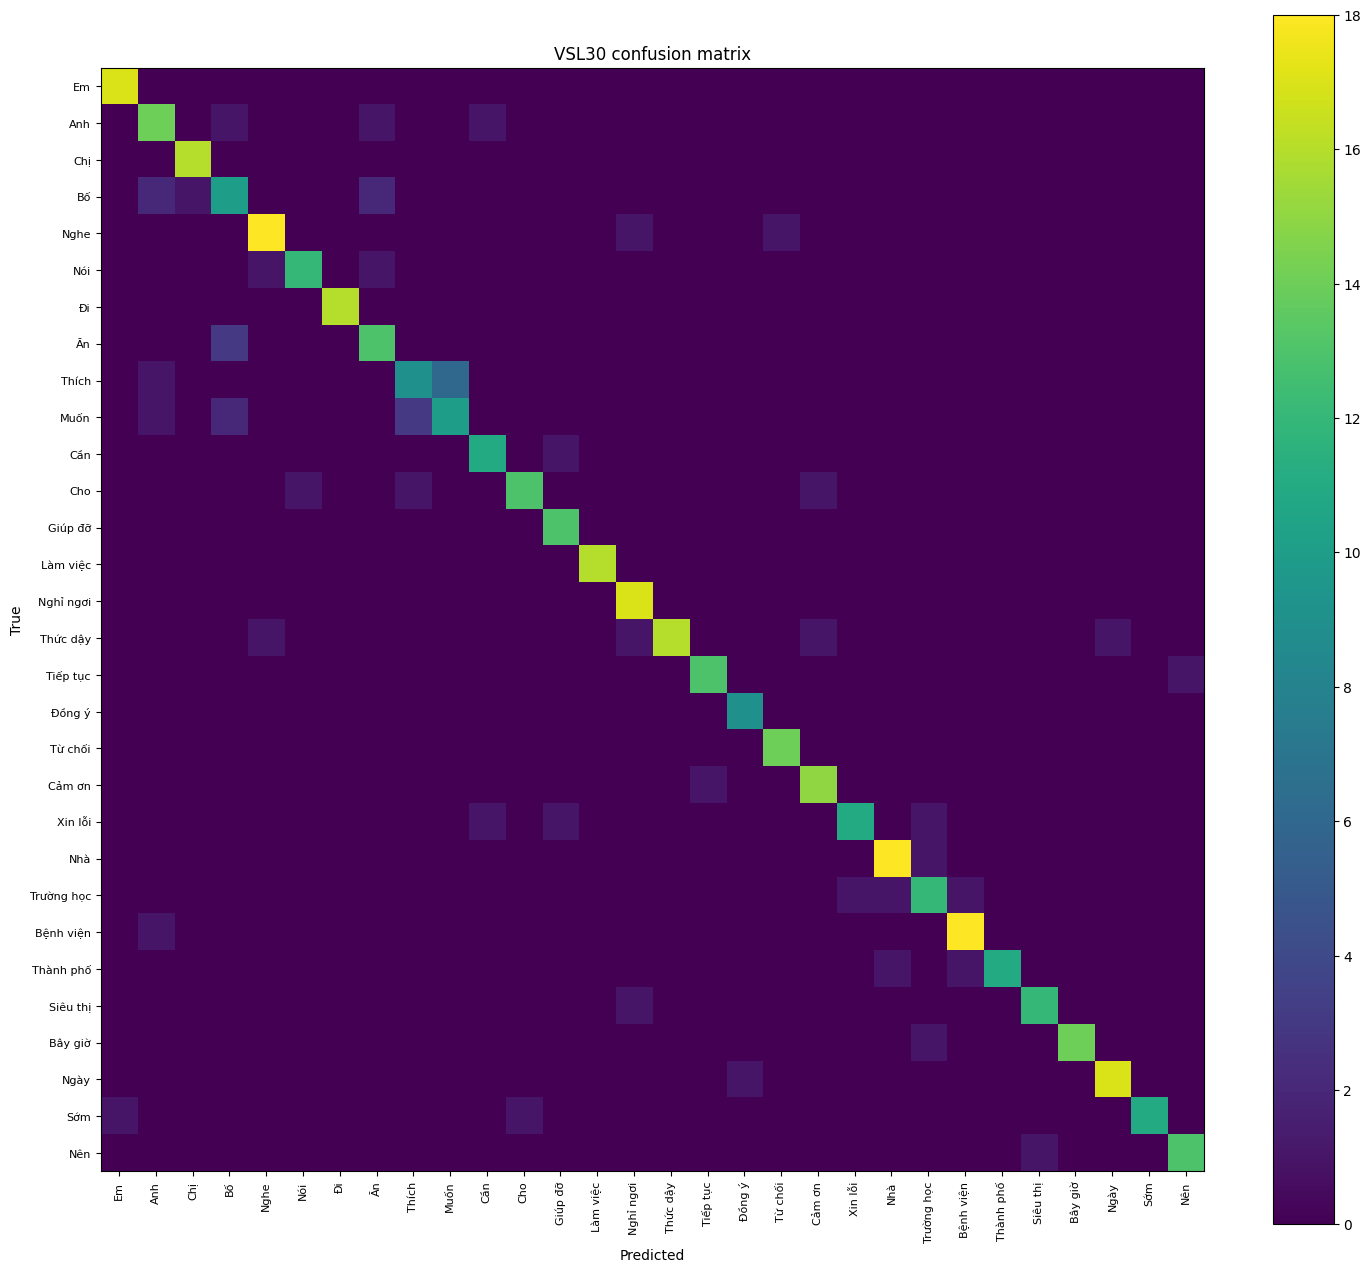

,true,most_confused_with,count,class_total,error_rate_to_pair
5,Thích,Muốn,6,16,0.375000
4,Ăn,Bố,3,16,0.187500
6,Muốn,Thích,3,16,0.187500
1,Bố,Anh,2,15,0.133333
7,Cần,Giúp đỡ,1,12,0.083333
16,Thành phố,Nhà,1,13,0.076923
17,Siêu thị,Nghỉ ngơi,1,13,0.076923
20,Sớm,Em,1,13,0.076923
3,Nói,Nghe,1,14,0.071429
10,Tiếp tục,Nên,1,14,0.071429


In [22]:
# ============================================================
# 21. CONFUSION MATRIX + HARDEST PAIRS
# ============================================================
cm = confusion_matrix(
    y_true,y_pred,
    labels=np.arange(len(TARGET_GLOSSES))
)

cm_df = pd.DataFrame(
    cm,index=TARGET_GLOSSES,columns=TARGET_GLOSSES
)
cm_df.to_csv(
    WORK_DIR/"confusion_matrix.csv",
    encoding="utf-8-sig"
)

plt.figure(figsize=(15,13))
plt.imshow(cm)
plt.xticks(range(len(TARGET_GLOSSES)),TARGET_GLOSSES,rotation=90,fontsize=8)
plt.yticks(range(len(TARGET_GLOSSES)),TARGET_GLOSSES,fontsize=8)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("VSL30 confusion matrix")
plt.colorbar()
plt.tight_layout()
plt.savefig(WORK_DIR/"confusion_matrix.png",dpi=180)
plt.show()

pairs=[]
for i in range(len(TARGET_GLOSSES)):
    row=cm[i].copy()
    row[i]=0
    j=int(row.argmax())
    if row[j]>0:
        pairs.append({
            "true":TARGET_GLOSSES[i],
            "most_confused_with":TARGET_GLOSSES[j],
            "count":int(row[j]),
            "class_total":int(cm[i].sum()),
            "error_rate_to_pair":float(row[j]/max(1,cm[i].sum())),
        })

hard_pairs_df=pd.DataFrame(pairs).sort_values(
    ["count","error_rate_to_pair"],ascending=False
)
display(hard_pairs_df.head(20))
hard_pairs_df.to_csv(
    WORK_DIR/"hard_confusion_pairs.csv",
    index=False,encoding="utf-8-sig"
)

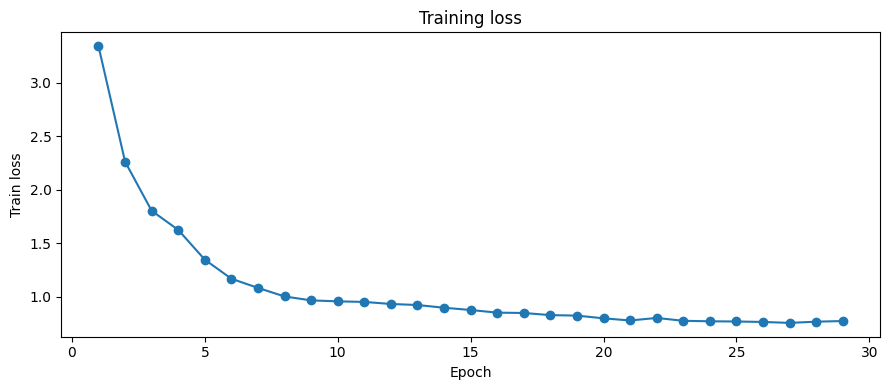

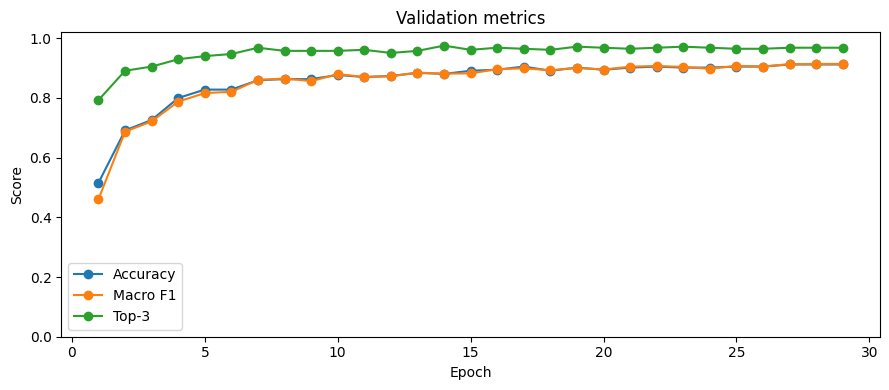

In [23]:
# ============================================================
# 22. TRAINING CURVES
# ============================================================
hist=pd.DataFrame(history)

if len(hist):
    plt.figure(figsize=(9,4))
    plt.plot(hist["epoch"],hist["train_loss"],marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Train loss")
    plt.title("Training loss")
    plt.tight_layout()
    plt.savefig(WORK_DIR/"training_loss.png",dpi=160)
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(hist["epoch"],hist["val_acc"],marker="o",label="Accuracy")
    plt.plot(hist["epoch"],hist["val_macro_f1"],marker="o",label="Macro F1")
    plt.plot(hist["epoch"],hist["val_top3"],marker="o",label="Top-3")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.ylim(0,1.02)
    plt.title("Validation metrics")
    plt.legend()
    plt.tight_layout()
    plt.savefig(WORK_DIR/"validation_metrics.png",dpi=160)
    plt.show()

In [24]:
# ============================================================
# 23. SAVE LABELS / CONFIG / FINAL SUMMARY
# ============================================================
label_map = {
    "label_to_idx":label_to_idx,
    "idx_to_label":{str(k):v for k,v in idx_to_label.items()},
}
(WORK_DIR/"label_map.json").write_text(
    json.dumps(label_map,ensure_ascii=False,indent=2),
    encoding="utf-8"
)

summary = {
    "target_glosses":TARGET_GLOSSES,
    "num_classes":len(TARGET_GLOSSES),
    "canonical_train_before_val":len(train_all_df),
    "train_final":len(train_full_df),
    "validation":len(val_df),
    "test":len(test_df),
    "augmented_train_added":len(aug_df),
    "blacklist_unique_ids":sum(len(x) for x in BAD_VIDEO_IDS.values()),    "mode":"keypoint_only",
    "baseline_v3_acc":BASELINE_V3_ACC,
    "baseline_v3_macro_f1":BASELINE_V3_MACRO_F1,
    "pretrain_checkpoint":str(PRETRAIN_PATH),
    "pretrained_tensors_loaded":len(loaded_report),
    "best_val_macro_f1":float(best_score),
    "best_epoch":int(best["epoch"]),
    "test_metrics":{k:float(v) for k,v in test_metrics.items()},
}

(WORK_DIR/"summary.json").write_text(
    json.dumps(summary,ensure_ascii=False,indent=2),
    encoding="utf-8"
)

print(json.dumps(summary,ensure_ascii=False,indent=2))

{
  "target_glosses": [
    "Em",
    "Anh",
    "Chị",
    "Bố",
    "Nghe",
    "Nói",
    "Đi",
    "Ăn",
    "Thích",
    "Muốn",
    "Cần",
    "Cho",
    "Giúp đỡ",
    "Làm việc",
    "Nghỉ ngơi",
    "Thức dậy",
    "Tiếp tục",
    "Đồng ý",
    "Từ chối",
    "Cảm ơn",
    "Xin lỗi",
    "Nhà",
    "Trường học",
    "Bệnh viện",
    "Thành phố",
    "Siêu thị",
    "Bây giờ",
    "Ngày",
    "Sớm",
    "Nên"
  ],
  "num_classes": 30,
  "canonical_train_before_val": 1875,
  "train_final": 3140,
  "validation": 285,
  "test": 463,
  "augmented_train_added": 1550,
  "blacklist_unique_ids": 86,
  "mode": "keypoint_only",
  "baseline_v3_acc": 0.8618,
  "baseline_v3_macro_f1": 0.8628,
  "pretrain_checkpoint": "/kaggle/input/datasets/dsfsdfdssdfdsf/output-ca-notebook-train/vsl_train_from_keypoints/export/best_vsl_metric_encoder.pt",
  "pretrained_tensors_loaded": 64,
  "best_val_macro_f1": 0.9141105862225797,
  "best_epoch": 28,
  "test_metrics": {
    "acc": 0.8833693304535637,
    

In [25]:
# ============================================================
# 24. V3 mode confirmation
# ============================================================
print("This model is already KEYPOINT-ONLY.")


This model is already KEYPOINT-ONLY.


In [26]:
# ============================================================
# 25. OUTPUT FILES
# ============================================================
print("WORK_DIR:",WORK_DIR)

for p in sorted(WORK_DIR.iterdir()):
    if p.is_file():
        print(f"{p.name:40s} {p.stat().st_size/1024**2:.2f} MB")

print("\nOn Kaggle: Save Version để giữ toàn bộ output.")

WORK_DIR: /kaggle/working/vsl30_v3_1_final_safe
best_vsl30_keypoint.pt                   7.50 MB
classification_report.csv                0.00 MB
confusion_matrix.csv                     0.00 MB
confusion_matrix.png                     0.13 MB
counts_after_blacklist.csv               0.00 MB
hard_confusion_pairs.csv                 0.00 MB
label_map.json                           0.00 MB
removed_bad_video_ids.csv                0.00 MB
split_counts.csv                         0.00 MB
summary.json                             0.00 MB
test_predictions.csv                     0.05 MB
training_history.csv                     0.00 MB
training_loss.png                        0.03 MB
validation_metrics.png                   0.05 MB

On Kaggle: Save Version để giữ toàn bộ output.


## Sau khi chạy xong

Output nằm tại:

```text
/kaggle/working/vsl30_v3_1_final_safe/
```

Gửi lại cho mình 5 file:

```text
summary.json
training_history.csv
classification_report.csv
confusion_matrix.csv
test_predictions.csv
```

Trong `summary.json` notebook sẽ ghi:

```text
final_verdict = USE_V3_1
```

nếu **cả Accuracy và Macro-F1 đều không thấp hơn baseline V3**.

Nếu không đạt, notebook ghi:

```text
final_verdict = KEEP_V3
```

=> Khi đó chốt lại model V3 hiện tại, không train thêm nữa.
